In [1]:
%%capture
!pip install torch torchvision timm matplotlib pandas scikit-learn tensorboard


In [2]:
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import OxfordIIITPet
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset, DataLoader
from torchvision.models import resnet18
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
if torch.cuda.is_available():
    print(f"GPU名称: {torch.cuda.get_device_name(0)}")

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

使用设备: cuda
GPU名称: Tesla T4


In [18]:
# 训练集增强
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    #transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 验证、测试集：禁止随机裁剪、随机翻转
val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 先下载完整数据集，**这里不给transform！**
full_dataset = OxfordIIITPet(root="./data", download=True, split="trainval")
labels = np.array([item[1] for item in full_dataset])

# 第一层划分：70%训练，30%临时(验证+测试)
sss_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=seed)
train_idx, temp_idx = next(sss_1.split(np.arange(len(full_dataset)), labels))

# 临时集合再对半分得到val:15%，test:15%
temp_labels = labels[temp_idx]
sss_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
val_rel_idx, test_rel_idx = next(sss_2.split(np.arange(len(temp_idx)), temp_labels))

val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

# ----------------修复点----------------
# 分别构造三个数据集实例，各自带上自己的transform，不要用Subset改dataset.transform
train_set = OxfordIIITPet(root="./data", split="trainval", transform=train_transform)
val_set = OxfordIIITPet(root="./data", split="trainval", transform=val_test_transform)
test_set = OxfordIIITPet(root="./data", split="trainval", transform=val_test_transform)

# 再用索引做子集
train_set = Subset(train_set, train_idx)
val_set = Subset(val_set, val_idx)
test_set = Subset(test_set, test_idx)
# --------------------------------------

batch_size = 32
# num_workers改为0，Kaggle偶尔多进程也会抛出奇怪worker错误
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

# ✅Day1检查点1：打印batch shape
imgs, labs = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}") # 预期 torch.Size([32, 3, 224, 224])


Batch shape: torch.Size([32, 3, 224, 224])


In [5]:
num_classes = 37
model = resnet18(weights="DEFAULT")
in_feat = model.fc.in_features
model.fc = nn.Linear(in_feat, num_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


In [6]:
os.makedirs("./output", exist_ok=True)
writer = SummaryWriter(log_dir="./runs/pet_baseline")

num_epochs = 15
best_val_acc = 0.0

def validate(model, loader, criterion, dev):
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0
    with torch.no_grad():
        for imgs, labs in loader:
            imgs, labs = imgs.to(dev), labs.to(dev)
            out = model(imgs)
            loss = criterion(out, labs)
            total_loss += loss.item()
            _, pred = torch.max(out, dim=1)
            total_samples += labs.size(0)
            correct += torch.sum(pred == labs).item()
    avg_loss = total_loss / len(loader)
    acc = correct / total_samples
    return avg_loss, acc

for epoch in range(num_epochs):
    model.train()
    train_loss_sum = 0.0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)

        optimizer.zero_grad()   # 梯度清零，每个batch开头
        outputs = model(imgs)
        loss = criterion(outputs, labs)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(train_loader)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f"Epoch[{epoch+1:2d}/{num_epochs}] | TrainLoss:{train_loss:.4f} | ValLoss:{val_loss:.4f} | ValAcc:{val_acc:.4f}")

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Acc/val", val_acc, epoch)

    # 保存最优权重
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "./output/best_model.pth")

writer.close()
print(f"\n✅Day1完成，最佳验证集准确率 = {best_val_acc:.4f}")

Epoch[ 1/15] | TrainLoss:1.8900 | ValLoss:0.7642 | ValAcc:0.8551
Epoch[ 2/15] | TrainLoss:0.5963 | ValLoss:0.4863 | ValAcc:0.8895
Epoch[ 3/15] | TrainLoss:0.3042 | ValLoss:0.3831 | ValAcc:0.9185
Epoch[ 4/15] | TrainLoss:0.1833 | ValLoss:0.3384 | ValAcc:0.9040
Epoch[ 5/15] | TrainLoss:0.1175 | ValLoss:0.3597 | ValAcc:0.9149
Epoch[ 6/15] | TrainLoss:0.0629 | ValLoss:0.2993 | ValAcc:0.9203
Epoch[ 7/15] | TrainLoss:0.0499 | ValLoss:0.2927 | ValAcc:0.9203
Epoch[ 8/15] | TrainLoss:0.0352 | ValLoss:0.2666 | ValAcc:0.9221
Epoch[ 9/15] | TrainLoss:0.0307 | ValLoss:0.2864 | ValAcc:0.9203
Epoch[10/15] | TrainLoss:0.0251 | ValLoss:0.2951 | ValAcc:0.9257
Epoch[11/15] | TrainLoss:0.0203 | ValLoss:0.2818 | ValAcc:0.9275
Epoch[12/15] | TrainLoss:0.0158 | ValLoss:0.2856 | ValAcc:0.9257
Epoch[13/15] | TrainLoss:0.0125 | ValLoss:0.2646 | ValAcc:0.9149
Epoch[14/15] | TrainLoss:0.0125 | ValLoss:0.2670 | ValAcc:0.9185
Epoch[15/15] | TrainLoss:0.0106 | ValLoss:0.2843 | ValAcc:0.9203

✅Day1完成，最佳验证集准确率 = 0.927

In [7]:
from IPython.display import FileLink
# 把整个pet_baseline打包压缩
!zip -r pet_baseline.zip ./runs/pet_baseline
# 生成蓝色下载链接
display(FileLink("./pet_baseline.zip"))


  adding: runs/pet_baseline/ (stored 0%)
  adding: runs/pet_baseline/events.out.tfevents.1788510455.de58d625c3da.58.0 (deflated 59%)


/kaggle/working/pet_baseline.zip

==========Baseline(A组)测试集结果==========
Test Top‑1 Acc: 0.9221
Macro‑F1: 0.9214
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.74      0.93      0.82        15
           2       0.93      0.87      0.90        15
           3       1.00      0.93      0.97        15
           4       0.93      0.93      0.93        15
           5       0.69      0.73      0.71        15
           6       0.79      1.00      0.88        15
           7       0.88      1.00      0.94        15
           8       0.94      1.00      0.97        15
           9       1.00      0.80      0.89        15
          10       0.81      0.87      0.84        15
          11       0.79      0.79      0.79        14
          12       1.00      0.93      0.96        14
          13       1.00      0.93      0.97        15
          14       0.94      1.00      0.97        15
          15       1.00      1.00      1.00        15
   

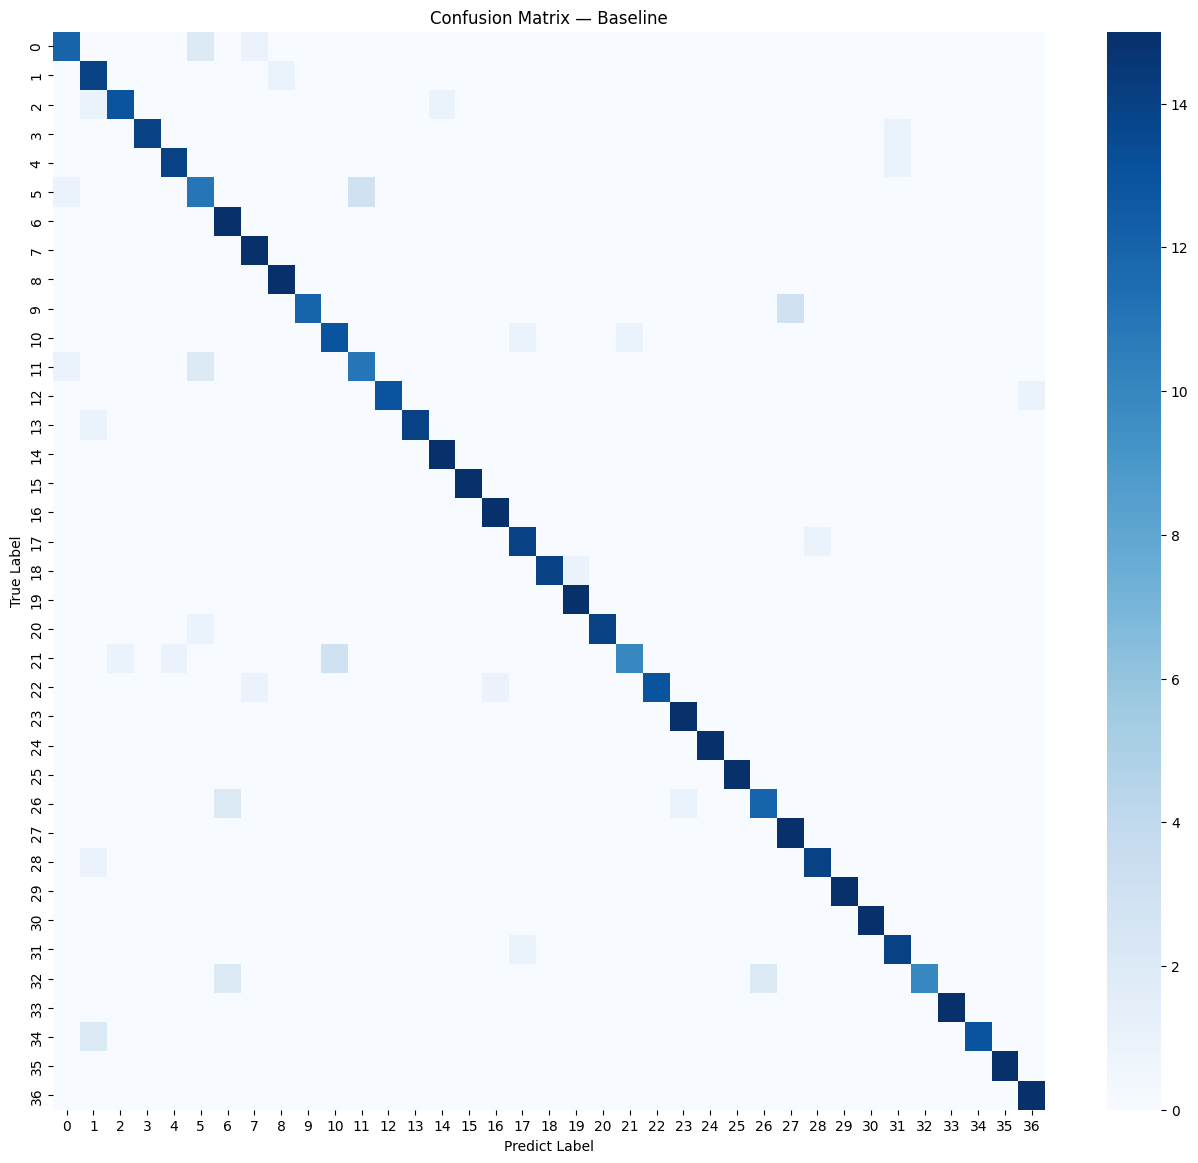

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 加载Day1训练好的Baseline最优权重
model.load_state_dict(torch.load("./output/best_model.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labs in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        pred = torch.argmax(outputs, dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labs.numpy())

# 指标输出
print("==========Baseline(A组)测试集结果==========")
report = classification_report(all_labels, all_preds, output_dict=True)
test_acc = report["accuracy"]
macro_f1 = report["macro avg"]["f1-score"]
print(f"Test Top‑1 Acc: {test_acc:.4f}")
print(f"Macro‑F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds))

# 绘制混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16,14))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix — Baseline")
plt.ylabel("True Label")
plt.xlabel("Predict Label")
plt.savefig("./output/cm_baseline.png", dpi=150)
plt.show()


✅ 预测正确样本 Grad-CAM


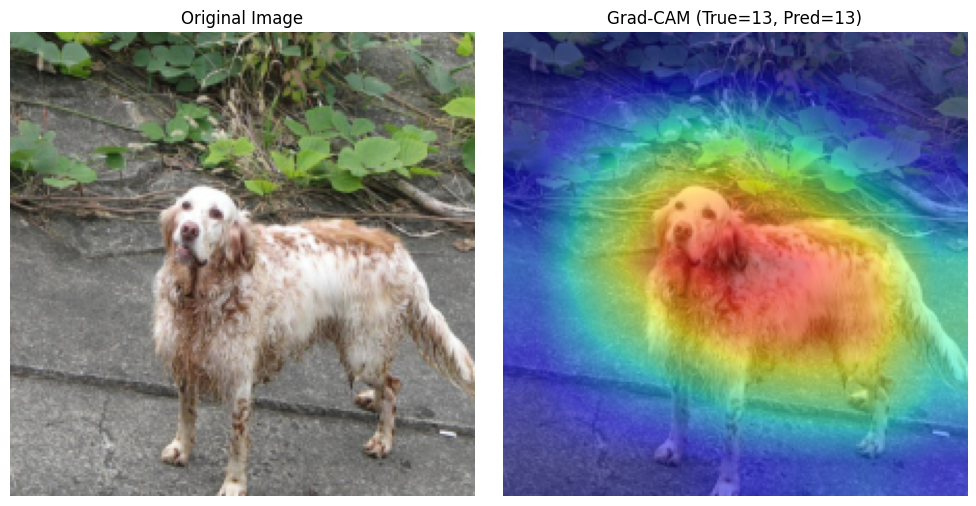

❌ 预测错误样本 Grad-CAM


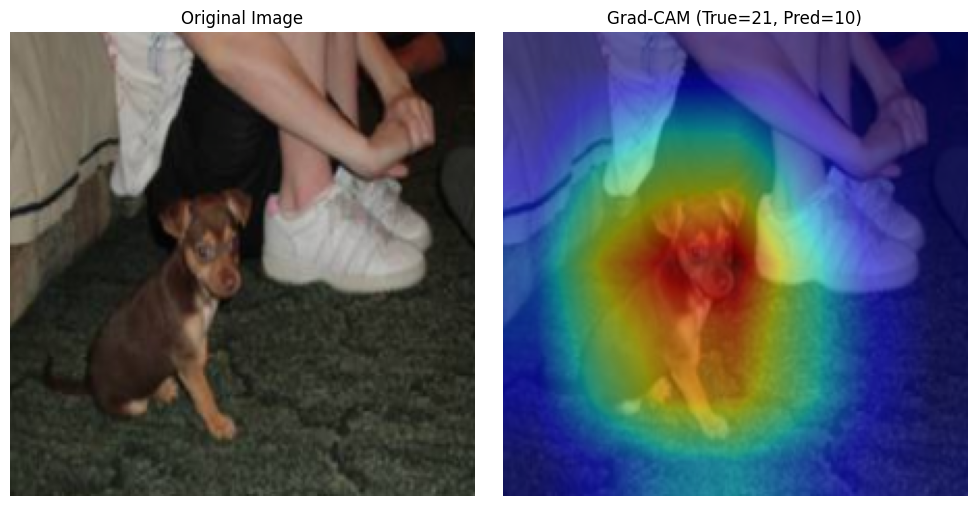

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ========== 纯PyTorch手写Grad-CAM ==========
class GradCAMManual:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        # 注册钩子
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        # 取目标类别的分数
        score = output[0, target_class]
        score.backward(retain_graph=True)

        # 全局平均池化梯度得到权重
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        # 加权求和
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = F.relu(cam)
        # 归一化到0-1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        # 上采样到224x224
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        return cam[0, 0].cpu().numpy()


# 初始化Grad-CAM，目标层是ResNet18最后一个卷积块
cam_extractor = GradCAMManual(model, model.layer4[-1])

# 从测试集找1张预测正确、1张预测错误的样本
correct_img = None
wrong_img = None
correct_target = None
wrong_target = None
correct_pred = None
wrong_pred = None

for imgs, labs in test_loader:
    imgs = imgs.to(device)
    with torch.no_grad():
        out = model(imgs)
        preds = torch.argmax(out, dim=1)
    for i in range(len(imgs)):
        if preds[i] == labs[i] and correct_img is None:
            correct_img = imgs[i]
            correct_target = labs[i].item()
            correct_pred = preds[i].item()
        if preds[i] != labs[i] and wrong_img is None:
            wrong_img = imgs[i]
            wrong_target = labs[i].item()
            wrong_pred = preds[i].item()
    if correct_img is not None and wrong_img is not None:
        break


def plot_gradcam(tensor_img, target_cls, save_name, title_text):
    input_tensor = tensor_img.unsqueeze(0).to(device)
    cam_map = cam_extractor.generate(input_tensor, target_cls)

    # 反归一化原图，用于显示
    img_np = tensor_img.cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    # 叠加热力图
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(img_np)
    axes[1].imshow(cam_map, cmap="jet", alpha=0.5)
    axes[1].set_title(title_text)
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(f"./output/{save_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print("✅ 预测正确样本 Grad-CAM")
plot_gradcam(correct_img, correct_target, "gradcam_correct",
             f"Grad-CAM (True={correct_target}, Pred={correct_pred})")

print("❌ 预测错误样本 Grad-CAM")
plot_gradcam(wrong_img, wrong_target, "gradcam_wrong",
             f"Grad-CAM (True={wrong_target}, Pred={wrong_pred})")


In [19]:
import os
import torch
import torch.nn as nn
from torchvision.models import resnet18
from torch.utils.tensorboard import SummaryWriter

num_classes = 37
model = resnet18(weights="DEFAULT")
in_feat = model.fc.in_features
model.fc = nn.Linear(in_feat, num_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

os.makedirs("./output", exist_ok=True)
writer = SummaryWriter(log_dir="./runs/pet_ablation_no_flip")

num_epochs = 15
best_val_acc = 0.0

def validate(model, loader, criterion, dev):
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0
    with torch.no_grad():
        for imgs, labs in loader:
            imgs, labs = imgs.to(dev), labs.to(dev)
            out = model(imgs)
            loss = criterion(out, labs)
            total_loss += loss.item()
            _, pred = torch.max(out, dim=1)
            total_samples += labs.size(0)
            correct += torch.sum(pred == labs).item()
    avg_loss = total_loss / len(loader)
    acc = correct / total_samples
    return avg_loss, acc

for epoch in range(num_epochs):
    model.train()
    train_loss_sum = 0.0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labs)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(train_loader)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f"Epoch[{epoch+1:2d}/{num_epochs}] | TrainLoss:{train_loss:.4f} | ValLoss:{val_loss:.4f} | ValAcc:{val_acc:.4f}")

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Acc/val", val_acc, epoch)

    # 消融模型单独保存，不覆盖Day1的baseline
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "./output/best_model_ablation_no_flip.pth")

writer.close()
print(f"\n✅ 消融实验完成（移除RandomHorizontalFlip），最佳验证集准确率 = {best_val_acc:.4f}")



Epoch[ 1/15] | TrainLoss:1.9085 | ValLoss:0.7513 | ValAcc:0.8714
Epoch[ 2/15] | TrainLoss:0.5546 | ValLoss:0.4775 | ValAcc:0.8913
Epoch[ 3/15] | TrainLoss:0.2636 | ValLoss:0.3920 | ValAcc:0.9094
Epoch[ 4/15] | TrainLoss:0.1340 | ValLoss:0.3349 | ValAcc:0.9185
Epoch[ 5/15] | TrainLoss:0.0719 | ValLoss:0.3082 | ValAcc:0.9185
Epoch[ 6/15] | TrainLoss:0.0455 | ValLoss:0.2898 | ValAcc:0.9185
Epoch[ 7/15] | TrainLoss:0.0304 | ValLoss:0.2796 | ValAcc:0.9257
Epoch[ 8/15] | TrainLoss:0.0266 | ValLoss:0.2572 | ValAcc:0.9257
Epoch[ 9/15] | TrainLoss:0.0197 | ValLoss:0.2581 | ValAcc:0.9366
Epoch[10/15] | TrainLoss:0.0139 | ValLoss:0.2503 | ValAcc:0.9330
Epoch[11/15] | TrainLoss:0.0117 | ValLoss:0.2657 | ValAcc:0.9257
Epoch[12/15] | TrainLoss:0.0094 | ValLoss:0.2433 | ValAcc:0.9366
Epoch[13/15] | TrainLoss:0.0101 | ValLoss:0.2469 | ValAcc:0.9239
Epoch[14/15] | TrainLoss:0.0088 | ValLoss:0.2624 | ValAcc:0.9167
Epoch[15/15] | TrainLoss:0.0077 | ValLoss:0.2755 | ValAcc:0.9293

✅ 消融实验完成（移除RandomHorizon

In [20]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 重建模型结构，加载消融实验权重
model_ablation = resnet18(weights=None)
num_classes = 37
model_ablation.fc = nn.Linear(model_ablation.fc.in_features, num_classes)
model_ablation = model_ablation.to(device)
model_ablation.load_state_dict(torch.load("./output/best_model_ablation_no_flip.pth", map_location=device))
model_ablation.eval()

# 在测试集上评估
all_preds_b = []
all_labels_b = []
with torch.no_grad():
    for imgs, labs in test_loader:
        imgs = imgs.to(device)
        outputs = model_ablation(imgs)
        pred = torch.argmax(outputs, dim=1)
        all_preds_b.extend(pred.cpu().numpy())
        all_labels_b.extend(labs.numpy())

print("========== B组消融（移除RandomHorizontalFlip）测试集结果 ==========")
report_b = classification_report(all_labels_b, all_preds_b, output_dict=True)
test_acc_b = report_b["accuracy"]
macro_f1_b = report_b["macro avg"]["f1-score"]
print(f"Test Top-1 Acc: {test_acc_b:.4f}")
print(f"Macro-F1: {macro_f1_b:.4f}")
print(classification_report(all_labels_b, all_preds_b))


========== B组消融（移除RandomHorizontalFlip）测试集结果 ==========
Test Top-1 Acc: 0.9149
Macro-F1: 0.9141
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.71      0.80      0.75        15
           2       0.75      0.80      0.77        15
           3       0.93      0.93      0.93        15
           4       0.86      0.80      0.83        15
           5       0.67      0.67      0.67        15
           6       0.88      1.00      0.94        15
           7       1.00      1.00      1.00        15
           8       1.00      0.87      0.93        15
           9       1.00      0.93      0.97        15
          10       0.87      0.87      0.87        15
          11       0.76      0.93      0.84        14
          12       0.87      0.93      0.90        14
          13       1.00      0.80      0.89        15
          14       0.94      1.00      0.97        15
          15       1.00      0.93      

In [21]:
from IPython.display import FileLink
!zip -r day2_output.zip ./output
display(FileLink("./day2_output.zip"))


  adding: output/ (stored 0%)
  adding: output/best_model.pth (deflated 7%)
  adding: output/cm_baseline.png (deflated 36%)
  adding: output/gradcam_correct.png (deflated 3%)
  adding: output/best_model_ablation_no_flip.pth (deflated 7%)
  adding: output/gradcam_wrong.png (deflated 4%)


/kaggle/working/day2_output.zip